# StepVerify × MathDial Labeling Pipeline - Full Statistics

This notebook is a **read-only analysis** notebook. It does not modify any of the pipeline notebooks or data files.

It reports statistics for every stage of the labeling pipeline defined in `final_00_01_labeling_stepverify__with__math_dial__refactored_code.ipynb`:

1. Raw inputs: `mathdial_df.csv` and `stepverify.json` (before any matching)
2. Stage 1 - Student conversation matching (`stepverify_0.9__student_converation_match.json`)
3. Stage 2 - Teacher turn matching (`stepverify_0.9__teacher_turn_match.json`), including turns that were matched to a MathDial teacher turn but **rejected** (not finally selected) because the similarity score was below the threshold
4. Final output: `stepverify_labeled_0.9.json` (after applying only accepted labels and dropping conversations with incomplete pedagogy labels)
5. `pedagogy` / `student_error_type (error_category)` distributions and their relationship at every stage where they are available

In [2]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
  from google.colab import drive

  drive.mount('/content/drive') # load google drive
  os.chdir('/content/drive/My Drive/Thesis_Repository/Final_Google_Drive') # change directory to the current working directory

In [3]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

# Raw inputs (before any matching / labeling)
MATHDIAL_CSV_PATH = Path("./original_data/mathdial_df.csv")
STEPVERIFY_RAW_PATH = Path("./original_data/stepverify.json")

# Final labeled output produced by final_00_01_labeling_stepverify__with__math_dial__refactored_code.ipynb
STEPVERIFY_LABELED_PATH = Path("./data/stepverify_labeled_0.9.json")

# Intermediate / meta outputs of the matching pipeline (Stage 1 and Stage 2)
META_DIR = Path("./data/meta_data")
STUDENT_CONVERSATION_MATCH_PATH = META_DIR / "stepverify_0.9__student_converation_match.json"
TEACHER_TURN_MATCH_PATH = META_DIR / "stepverify_0.9__teacher_turn_match.json"
STUDENT_CONVERSATION_SUMMARY_PATH = META_DIR / "stepverify_0.9__student_conversation_similiary_summary.json"
TEACHER_TURN_MATCH_SUMMARY_PATH = META_DIR / "stepverify_0.9__teacher_turn_match_summary.json"

In [73]:
mathdial_df = pd.read_csv(MATHDIAL_CSV_PATH)

with open(STEPVERIFY_RAW_PATH, "r", encoding="utf-8") as f:
    stepverify_raw = json.load(f)
stepverify_raw_df = pd.DataFrame(stepverify_raw)

with open(STEPVERIFY_LABELED_PATH, "r", encoding="utf-8") as f:
    stepverify_labeled = json.load(f)
stepverify_labeled_df = pd.DataFrame(stepverify_labeled)

with open(STUDENT_CONVERSATION_MATCH_PATH, "r", encoding="utf-8") as f:
    student_conversation_match_df = pd.DataFrame(json.load(f))

with open(TEACHER_TURN_MATCH_PATH, "r", encoding="utf-8") as f:
    teacher_turn_match_df = pd.DataFrame(json.load(f))

with open(STUDENT_CONVERSATION_SUMMARY_PATH, "r", encoding="utf-8") as f:
    student_conversation_summary = json.load(f)

with open(TEACHER_TURN_MATCH_SUMMARY_PATH, "r", encoding="utf-8") as f:
    teacher_turn_match_summary = json.load(f)

print("mathdial_df:", mathdial_df.shape)
print("stepverify_raw_df:", stepverify_raw_df.shape)
print("stepverify_labeled_df:", stepverify_labeled_df.shape)
print("student_conversation_match_df:", student_conversation_match_df.shape)
print("teacher_turn_match_df:", teacher_turn_match_df.shape)

mathdial_df: (2861, 11)
stepverify_raw_df: (1002, 10)
stepverify_labeled_df: (991, 10)
student_conversation_match_df: (1002, 10)
teacher_turn_match_df: (2004, 17)


## 1. Raw datasets - before any matching

`mathdial_df.csv` (all MathDial rows used as the labeling source) vs `stepverify.json` (the raw, unlabeled StepVerify dataset).

In [74]:
raw_overview = pd.DataFrame(
    [
        {
            "dataset": "mathdial_df (raw)",
            "n_rows": len(mathdial_df),
            "n_unique_question": mathdial_df["question"].nunique(),
        },
        {
            "dataset": "stepverify.json (raw)",
            "n_rows": len(stepverify_raw_df),
            "n_unique_question": stepverify_raw_df["problem"].nunique(),
        },
    ]
)
raw_overview

,dataset,n_rows,n_unique_question
0,mathdial_df (raw),2861,1111
1,stepverify.json (raw),1002,612


In [75]:
# StepVerify raw dialog_history turn-count distribution (sanity check reproduced from final_00_01)
stepverify_raw_df["n_dialog_turns"] = stepverify_raw_df["dialog_history"].apply(len)
print("StepVerify raw - dialog_history turn count distribution:")
print(stepverify_raw_df["n_dialog_turns"].value_counts().sort_index())
print()
print("StepVerify raw - error_category (student_error_type) distribution:")
print(stepverify_raw_df["error_category"].value_counts(dropna=False))

StepVerify raw - dialog_history turn count distribution:
n_dialog_turns
3    967
4     29
5      4
6      2
Name: count, dtype: int64

StepVerify raw - error_category (student_error_type) distribution:
error_category
Misunderstanding of a question                     287
Extra quantity or Missing quantity                 240
Missing / Wrong factual knowledge                  140
Calculation error easily solved by a calculator    128
None of the above                                   87
Reached correct solution but proceeded further      70
Unit conversion error                               50
Name: count, dtype: int64


## 2. Stage 1 - Student conversation matching

For every StepVerify row, the pipeline looks up MathDial rows with the same `question`, then scores student-utterance similarity (`score_student_turn_similarity`) and keeps the single best-matching MathDial row (`mathdial_row_id`). This stage does **not** decide pedagogy labels yet - it only selects which MathDial conversation each StepVerify conversation will be compared against in Stage 2.

In [76]:
print("n_student_conversation_similiary_result:", student_conversation_summary["n_student_conversation_similiary_result"])
print()
print("status distribution (matched vs no_mathdial_question_candidate):")
print(pd.Series(student_conversation_summary["student_conversation_similarity_result_status"]))
print()
print("best_student_utterence_similarity_score distribution (binned):")
print(pd.Series(student_conversation_summary["student_conversation_similarity_score_distribution"]))

n_student_conversation_similiary_result: 1002

status distribution (matched vs no_mathdial_question_candidate):
matched    1002
dtype: int64

best_student_utterence_similarity_score distribution (binned):
0.0~0.2       1
0.2~0.4       1
0.4~0.6       0
0.6~0.8       2
0.8~0.9       3
0.9~0.99     27
0.99~1.0    968
dtype: int64


In [77]:
# Rows that could not be matched to any MathDial conversation at Stage 1 (mathdial_row_id is missing)
stage1_unmatched_df = student_conversation_match_df[student_conversation_match_df["status"] != "matched"]
print("Stage 1 - rows with NO MathDial candidate at all (dropped before Stage 2):", len(stage1_unmatched_df))
stage1_unmatched_df

Stage 1 - rows with NO MathDial candidate at all (dropped before Stage 2): 0


,stepverify_row_id,mathdial_row_id,matched_question_in_mathdial,number_of_question_in_mathdial,best_student_utterence_similarity_score,second_best_similarity_score,difference__best_and_second_best,score_source,student_utterance_pairwise_socres,status


## 3. Stage 2 - Teacher turn matching (accepted vs matched-but-rejected)

Every teacher turn in a StepVerify conversation is compared against every **labeled** MathDial teacher turn in the Stage 1 selected conversation. The best-scoring candidate is kept, and it is only **accepted** (label actually transferred) if `mean_teacher_context_score >= threshold (0.9)`. Rows with `accepted = False` were matched to a candidate but **not** finally selected.

In [78]:
print("n_matched_teacher_turns (all candidate teacher-turn comparisons):", teacher_turn_match_summary["n_matched_teacher_turns"])
print()
print("status distribution:")
print(pd.Series(teacher_turn_match_summary["matched_teacher_turns_result_status"]))
print()
print("n_accepted_matched_teacher_turns:", teacher_turn_match_summary["n_accepted_matched_teacher_turns"])
print("n_rejected_matched_teacher_turns (matched but NOT finally selected):", teacher_turn_match_summary["n_rejected_matched_teacher_turns"])
print()
print("mean_teacher_context_score distribution for ACCEPTED turns (binned):")
print(pd.Series(teacher_turn_match_summary["accepted_matched_teacher_turns_distribution"]))

n_matched_teacher_turns (all candidate teacher-turn comparisons): 2004

status distribution:
accepted           1984
below_threshold      20
dtype: int64

n_accepted_matched_teacher_turns: 1984
n_rejected_matched_teacher_turns (matched but NOT finally selected): 20

mean_teacher_context_score distribution for ACCEPTED turns (binned):
0.0~0.2        0
0.2~0.4        0
0.4~0.6        0
0.6~0.8        0
0.8~0.9        0
0.9~0.99      24
0.99~1.0    1960
dtype: int64


In [79]:
# Teacher turns that WERE matched to a MathDial candidate but rejected for the final dataset
# (accepted == False, but a candidate mathdial_label__md_teacher_context still exists -> "below_threshold")
rejected_but_matched_df = teacher_turn_match_df[
    (~teacher_turn_match_df["accepted"]) & teacher_turn_match_df["mathdial_label__md_teacher_context"].notna()
]
print("Teacher turns matched to a candidate but rejected (below threshold):", len(rejected_but_matched_df))
print()
print("Their status distribution:")
print(rejected_but_matched_df["status"].value_counts())
print()
print("Candidate mathdial_label distribution for these rejected turns (label was seen but NOT transferred):")
print(rejected_but_matched_df["mathdial_label__md_teacher_context"].value_counts())

Teacher turns matched to a candidate but rejected (below threshold): 20

Their status distribution:
status
below_threshold    20
Name: count, dtype: int64

Candidate mathdial_label distribution for these rejected turns (label was seen but NOT transferred):
mathdial_label__md_teacher_context
generic    12
focus       6
probing     2
Name: count, dtype: int64


In [80]:
# Teacher turns with NO usable MathDial candidate at all (no labeled MathDial teacher turn / no MathDial question candidate)
no_candidate_df = teacher_turn_match_df[teacher_turn_match_df["mathdial_label__md_teacher_context"].isna()]
print("Teacher turns with NO candidate MathDial label at all:", len(no_candidate_df))
print(no_candidate_df["status"].value_counts())

Teacher turns with NO candidate MathDial label at all: 0
Series([], Name: count, dtype: int64)


In [81]:
# Accepted-only mathdial pedagogy label distribution (== the labels that were actually transferred)
accepted_df = teacher_turn_match_df[teacher_turn_match_df["accepted"]]
print("Accepted teacher turns - transferred pedagogy label distribution:")
print(accepted_df["mathdial_label__md_teacher_context"].value_counts())

Accepted teacher turns - transferred pedagogy label distribution:
mathdial_label__md_teacher_context
generic    822
probing    563
focus      536
telling     63
Name: count, dtype: int64


### 3.1 Relationship between StepVerify `error_category` and the Stage 2 `pedagogy` candidate/label

`teacher_turn_match.json` does not carry `error_category` directly, so it is joined back from the raw StepVerify dataset via `stepverify_row_id` (StepVerify's row order is preserved, so `stepverify_row_id` == positional index into `stepverify_raw_df`).

In [82]:
stepverify_raw_indexed = stepverify_raw_df.reset_index().rename(columns={"index": "stepverify_row_id"})
teacher_turn_match_with_category_df = teacher_turn_match_df.merge(
    stepverify_raw_indexed[["stepverify_row_id", "error_category"]],
    on="stepverify_row_id",
    how="left",
)

print("error_category x mathdial_label (ACCEPTED teacher turns only):")
display(
    pd.crosstab(
        teacher_turn_match_with_category_df.loc[teacher_turn_match_with_category_df["accepted"], "error_category"],
        teacher_turn_match_with_category_df.loc[teacher_turn_match_with_category_df["accepted"], "mathdial_label__md_teacher_context"],
    )
)

print()
print("error_category x mathdial_label (ALL candidates with a label, accepted + rejected):")
with_label_mask = teacher_turn_match_with_category_df["mathdial_label__md_teacher_context"].notna()
display(
    pd.crosstab(
        teacher_turn_match_with_category_df.loc[with_label_mask, "error_category"],
        teacher_turn_match_with_category_df.loc[with_label_mask, "mathdial_label__md_teacher_context"],
    )
)

error_category x mathdial_label (ACCEPTED teacher turns only):


mathdial_label__md_teacher_context,focus,generic,probing,telling
error_category,,,,
Calculation error easily solved by a calculator,63,88,93,7
Extra quantity or Missing quantity,145,197,118,17
Missing / Wrong factual knowledge,76,104,89,9
Misunderstanding of a question,147,254,152,15
None of the above,46,76,46,4
Reached correct solution but proceeded further,32,63,38,7
Unit conversion error,27,40,27,4



error_category x mathdial_label (ALL candidates with a label, accepted + rejected):


mathdial_label__md_teacher_context,focus,generic,probing,telling
error_category,,,,
Calculation error easily solved by a calculator,65,91,93,7
Extra quantity or Missing quantity,147,198,118,17
Missing / Wrong factual knowledge,76,106,89,9
Misunderstanding of a question,148,258,153,15
None of the above,46,78,46,4
Reached correct solution but proceeded further,32,63,38,7
Unit conversion error,28,40,28,4


## 4. Final labeled output - `stepverify_labeled_0.9.json`

This is the file produced after: (1) only accepted Stage-2 labels are applied, (2) columns are renamed/cleaned, and (3) any conversation with **at least one** teacher turn still missing a `pedagogy` label is dropped entirely (`drop_conversations_with_at_least_one_pedagogy_label`).

In [83]:
n_raw = len(stepverify_raw_df)
n_labeled = len(stepverify_labeled_df)
print(f"StepVerify raw rows: {n_raw}")
print(f"StepVerify labeled rows (0.9 threshold): {n_labeled}")
print(f"Rows dropped for having an incomplete pedagogy labeling: {n_raw - n_labeled}")
print(f"Unique problems in labeled output: {stepverify_labeled_df['problem'].nunique()}")
print()
print("error_category (student_error_type) distribution in the final labeled dataset:")
print(stepverify_labeled_df["error_category"].value_counts(dropna=False))

StepVerify raw rows: 1002
StepVerify labeled rows (0.9 threshold): 991
Rows dropped for having an incomplete pedagogy labeling: 11
Unique problems in labeled output: 609

error_category (student_error_type) distribution in the final labeled dataset:
error_category
misunderstanding_of_a_question                     284
extra_quantity_or_missing_quantity                 238
missing_wrong_factual_knowledge                    139
calculation_error_easily_solved_by_a_calculator    125
none_of_the_above                                   86
reached_correct_solution_but_proceeded_further      70
unit_conversion_error                               49
Name: count, dtype: int64


In [84]:
# Explode dialog_history to teacher/student turn level to compute final counts and pedagogy label distribution
teacher_turns_final = []
student_turns_final = []
for row in stepverify_labeled_df.to_dict(orient="records"):
    for turn in row["dialog_history"]:
        if turn.get("user") == "teacher":
            teacher_turns_final.append({"error_category": row["error_category"], "pedagogy": turn.get("pedagogy")})
        elif turn.get("user") == "student":
            student_turns_final.append({"error_category": row["error_category"]})

teacher_turns_final_df = pd.DataFrame(teacher_turns_final)
student_turns_final_df = pd.DataFrame(student_turns_final)

print("Total teacher turns in the final labeled dataset:", len(teacher_turns_final_df))
print("Total student turns in the final labeled dataset:", len(student_turns_final_df))
print("Total turns (teacher + student) in the final labeled dataset:", len(teacher_turns_final_df) + len(student_turns_final_df))
print()
print("Final pedagogy label distribution:")
print(teacher_turns_final_df["pedagogy"].value_counts(dropna=False))

Total teacher turns in the final labeled dataset: 1982
Total student turns in the final labeled dataset: 991
Total turns (teacher + student) in the final labeled dataset: 2973

Final pedagogy label distribution:
pedagogy
generic    820
probing    563
focus      536
telling     63
Name: count, dtype: int64


### 4.1 Relationship between `error_category` and final `pedagogy` label

In [85]:
print("error_category x pedagogy - counts (final labeled dataset, teacher-turn level):")
display(pd.crosstab(teacher_turns_final_df["error_category"], teacher_turns_final_df["pedagogy"]))

print()
print("error_category x pedagogy - row-normalized (%) (final labeled dataset):")
display(
    (pd.crosstab(teacher_turns_final_df["error_category"], teacher_turns_final_df["pedagogy"], normalize="index") * 100).round(1)
)

error_category x pedagogy - counts (final labeled dataset, teacher-turn level):


pedagogy,focus,generic,probing,telling
error_category,,,,
calculation_error_easily_solved_by_a_calculator,63,87,93,7
extra_quantity_or_missing_quantity,145,196,118,17
missing_wrong_factual_knowledge,76,104,89,9
misunderstanding_of_a_question,147,254,152,15
none_of_the_above,46,76,46,4
reached_correct_solution_but_proceeded_further,32,63,38,7
unit_conversion_error,27,40,27,4



error_category x pedagogy - row-normalized (%) (final labeled dataset):


pedagogy,focus,generic,probing,telling
error_category,,,,
calculation_error_easily_solved_by_a_calculator,25.2,34.8,37.2,2.8
extra_quantity_or_missing_quantity,30.5,41.2,24.8,3.6
missing_wrong_factual_knowledge,27.3,37.4,32.0,3.2
misunderstanding_of_a_question,25.9,44.7,26.8,2.6
none_of_the_above,26.7,44.2,26.7,2.3
reached_correct_solution_but_proceeded_further,22.9,45.0,27.1,5.0
unit_conversion_error,27.6,40.8,27.6,4.1


In [86]:
first_teacher_turns_final = []

for row in stepverify_labeled_df.to_dict(orient="records"):
    first_teacher_turn = next(
        (turn for turn in row["dialog_history"] if turn.get("user") == "teacher"),
        None,
    )
    if first_teacher_turn is not None:
        first_teacher_turns_final.append(
            {
                "error_category": row["error_category"],
                "pedagogy": first_teacher_turn.get("pedagogy"),
            }
        )

first_teacher_turns_final_df = pd.DataFrame(first_teacher_turns_final)

print("error_category x pedagogy - counts (first teacher turn only):")
display(
    pd.crosstab(
        first_teacher_turns_final_df["error_category"],
        first_teacher_turns_final_df["pedagogy"],
    )
)

print()
print("error_category x pedagogy - row-normalized (%) (first teacher turn only):")
display(
    (
        pd.crosstab(
            first_teacher_turns_final_df["error_category"],
            first_teacher_turns_final_df["pedagogy"],
            normalize="index",
        )
        * 100
    ).round(1)
)

error_category x pedagogy - counts (first teacher turn only):


pedagogy,focus,generic,probing,telling
error_category,,,,
calculation_error_easily_solved_by_a_calculator,19,84,21,1
extra_quantity_or_missing_quantity,13,186,35,4
missing_wrong_factual_knowledge,12,93,28,6
misunderstanding_of_a_question,14,227,41,2
none_of_the_above,7,67,12,0
reached_correct_solution_but_proceeded_further,4,53,11,2
unit_conversion_error,2,38,8,1



error_category x pedagogy - row-normalized (%) (first teacher turn only):


pedagogy,focus,generic,probing,telling
error_category,,,,
calculation_error_easily_solved_by_a_calculator,15.2,67.2,16.8,0.8
extra_quantity_or_missing_quantity,5.5,78.2,14.7,1.7
missing_wrong_factual_knowledge,8.6,66.9,20.1,4.3
misunderstanding_of_a_question,4.9,79.9,14.4,0.7
none_of_the_above,8.1,77.9,14.0,0.0
reached_correct_solution_but_proceeded_further,5.7,75.7,15.7,2.9
unit_conversion_error,4.1,77.6,16.3,2.0


## 5. End-to-end funnel summary

One table tracing every stage of `final_00_01_labeling_stepverify__with__math_dial__refactored_code.ipynb`, from the raw MathDial source all the way to the final labeled StepVerify dataset.

In [87]:
n_stage1_matched = int((student_conversation_match_df["status"] == "matched").sum())
n_stage1_unmatched = len(student_conversation_match_df) - n_stage1_matched

n_stage2_total = len(teacher_turn_match_df)
n_stage2_accepted = int(teacher_turn_match_df["accepted"].sum())
n_stage2_rejected_with_candidate = len(rejected_but_matched_df)
n_stage2_no_candidate = len(no_candidate_df)

funnel_df = pd.DataFrame(
    [
        {"stage": "MathDial (raw source pool)", "unit": "conversation", "count": len(mathdial_df)},
        {"stage": "StepVerify (raw)", "unit": "conversation", "count": n_raw},
        {"stage": "Stage 1 - matched to a MathDial conversation", "unit": "conversation", "count": n_stage1_matched},
        {"stage": "Stage 1 - NO MathDial candidate (same question missing)", "unit": "conversation", "count": n_stage1_unmatched},
        {"stage": "Stage 2 - teacher turns compared", "unit": "teacher turn", "count": n_stage2_total},
        {"stage": "Stage 2 - accepted (label transferred)", "unit": "teacher turn", "count": n_stage2_accepted},
        {"stage": "Stage 2 - matched but rejected (below threshold)", "unit": "teacher turn", "count": n_stage2_rejected_with_candidate},
        {"stage": "Stage 2 - no usable MathDial candidate at all", "unit": "teacher turn", "count": n_stage2_no_candidate},
        {"stage": "Final labeled StepVerify (all teacher turns labeled)", "unit": "conversation", "count": n_labeled},
        {"stage": "Dropped (>=1 teacher turn still unlabeled)", "unit": "conversation", "count": n_raw - n_labeled},
    ]
)
funnel_df

,stage,unit,count
0,MathDial (raw source pool),conversation,2861
1,StepVerify (raw),conversation,1002
2,Stage 1 - matched to a MathDial conversation,conversation,1002
3,Stage 1 - NO MathDial candidate (same question...,conversation,0
4,Stage 2 - teacher turns compared,teacher turn,2004
5,Stage 2 - accepted (label transferred),teacher turn,1984
6,Stage 2 - matched but rejected (below threshold),teacher turn,20
7,Stage 2 - no usable MathDial candidate at all,teacher turn,0
8,Final labeled StepVerify (all teacher turns la...,conversation,991
9,Dropped (>=1 teacher turn still unlabeled),conversation,11


In [88]:
# Independent audit of which MathDial rows contributed to records in the final output
# This cell uses only the data already loaded by this statistics notebook.

def canonical_dialog_history(record: dict) -> list[dict]:
    """Mirror the final dialogue cleanup while excluding the transferred label."""
    return [
        {
            key: value.lower() if isinstance(value, str) else value
            for key, value in turn.items()
            if key != "pedagogy"
        }
        for turn in record.get("dialog_history", [])[-3:]
    ]


def stable_stepverify_key(record: dict) -> str:
    """Build an identity key from fields preserved by the labeling pipeline."""
    identity_fields = (
        "topic",
        "reference_solution",
        "incorrect_index",
        "incorrect_step",
        "error_description",
        "student_correct_response",
    )
    identity = {field: record.get(field) for field in identity_fields}
    identity["dialog_history_without_pedagogy"] = canonical_dialog_history(record)
    return json.dumps(identity, ensure_ascii=False, sort_keys=True)


raw_records = stepverify_raw_df.to_dict(orient="records")
final_records = stepverify_labeled_df.to_dict(orient="records")
raw_keys = [stable_stepverify_key(record) for record in raw_records]
final_keys = [stable_stepverify_key(record) for record in final_records]

assert len(raw_keys) == len(set(raw_keys)), "The selected raw-record identity key is not unique."
raw_row_id_by_key = {key: row_id for row_id, key in enumerate(raw_keys)}
assert all(key in raw_row_id_by_key for key in final_keys), "A final record cannot be mapped to the raw StepVerify data."

final_stepverify_row_ids_from_output = {
    raw_row_id_by_key[key]
    for key in final_keys
}
assert len(final_stepverify_row_ids_from_output) == len(final_records)

# The pipeline keeps the last three turns and emits exactly one Stage-2 record per teacher turn.
expected_teacher_turn_keys = {
    (stepverify_row_id, turn_idx)
    for stepverify_row_id, record in enumerate(stepverify_raw)
    for turn_idx, turn in enumerate(record["dialog_history"][-3:])
    if str(turn.get("user", "")).strip().lower() == "teacher"
}
actual_teacher_turn_keys = list(
    zip(
        teacher_turn_match_df["stepverify_row_id"].astype(int),
        teacher_turn_match_df["turn_idx__sv_teacher_context"].astype(int),
    )
)
assert len(actual_teacher_turn_keys) == len(set(actual_teacher_turn_keys)), "Duplicate Stage-2 teacher-turn records found."
assert set(actual_teacher_turn_keys) == expected_teacher_turn_keys, "Stage-2 records do not cover the expected teacher turns exactly."

preexisting_pedagogy_turns = [
    (stepverify_row_id, turn_idx)
    for stepverify_row_id, record in enumerate(stepverify_raw)
    for turn_idx, turn in enumerate(record["dialog_history"][-3:])
    if str(turn.get("user", "")).strip().lower() == "teacher" and "pedagogy" in turn
]
assert not preexisting_pedagogy_turns, "Raw StepVerify contains pre-existing pedagogy fields."

# With no pre-existing labels, a conversation survives exactly when every teacher turn is accepted.
all_teacher_turns_accepted = teacher_turn_match_df.groupby("stepverify_row_id")["accepted"].all()
retained_stepverify_row_ids_from_stage2 = set(
    all_teacher_turns_accepted[all_teacher_turns_accepted].index.astype(int)
)
assert retained_stepverify_row_ids_from_stage2 == final_stepverify_row_ids_from_output, (
    "Stage-2 completeness does not reproduce the actual final StepVerify rows."
)

final_row_mask = teacher_turn_match_df["stepverify_row_id"].astype(int).isin(
    final_stepverify_row_ids_from_output
)
mathdial_row_ids_used_in_final = set(
    teacher_turn_match_df.loc[
        final_row_mask
        & teacher_turn_match_df["accepted"]
        & teacher_turn_match_df["mathdial_row_id"].notna(),
        "mathdial_row_id",
    ].astype(int)
)

stage1_final_rows = student_conversation_match_df.loc[
    student_conversation_match_df["stepverify_row_id"].astype(int).isin(
        final_stepverify_row_ids_from_output
    )
]
assert len(stage1_final_rows) == len(final_stepverify_row_ids_from_output)
assert stage1_final_rows["status"].eq("matched").all()
mathdial_row_ids_used_in_final_from_stage1 = set(
    stage1_final_rows["mathdial_row_id"].dropna().astype(int)
)
assert mathdial_row_ids_used_in_final == mathdial_row_ids_used_in_final_from_stage1, (
    "Stage 1 and Stage 2 disagree on the MathDial rows used by final records."
)

all_mathdial_row_ids = set(range(len(mathdial_df)))
assert mathdial_row_ids_used_in_final <= all_mathdial_row_ids

accepted_mathdial_row_ids_before_final_filter = set(
    teacher_turn_match_df.loc[
        teacher_turn_match_df["accepted"]
        & teacher_turn_match_df["mathdial_row_id"].notna(),
        "mathdial_row_id",
    ].astype(int)
)
overcounted_mathdial_row_ids = (
    accepted_mathdial_row_ids_before_final_filter - mathdial_row_ids_used_in_final
)

print("Independent audit passed.")
print(f"Raw StepVerify conversations: {len(raw_records)}")
print(f"Final StepVerify conversations: {len(final_records)}")
print(f"Dropped StepVerify conversations: {len(raw_records) - len(final_records)}")
print(f"MathDial rows accepted before final filtering: {len(accepted_mathdial_row_ids_before_final_filter)}")
print(f"MathDial rows contributing to final output: {len(mathdial_row_ids_used_in_final)}")
print(f"Rows overcounted by the previous formula: {len(overcounted_mathdial_row_ids)}")

Independent audit passed.
Raw StepVerify conversations: 1002
Final StepVerify conversations: 991
Dropped StepVerify conversations: 11
MathDial rows accepted before final filtering: 993
MathDial rows contributing to final output: 991
Rows overcounted by the previous formula: 2


In [89]:
# Verified end-to-end record flow from saved artifacts only.
# This cell does not execute the labeling pipeline.
import json as flow_json
from pathlib import Path as FlowPath

import pandas as flow_pd


def load_flow_json(path: FlowPath):
    with path.open("r", encoding="utf-8") as file:
        return flow_json.load(file)


def canonical_flow_dialog(record: dict) -> list[dict]:
    return [
        {
            key: value.lower() if isinstance(value, str) else value
            for key, value in turn.items()
            if key != "pedagogy"
        }
        for turn in record.get("dialog_history", [])[-3:]
    ]


def flow_record_key(record: dict) -> str:
    identity_fields = (
        "topic",
        "reference_solution",
        "incorrect_index",
        "incorrect_step",
        "error_description",
        "student_correct_response",
    )
    identity = {field: record.get(field) for field in identity_fields}
    identity["dialog_history_without_pedagogy"] = canonical_flow_dialog(record)
    return flow_json.dumps(identity, ensure_ascii=False, sort_keys=True)


flow_mathdial_df = flow_pd.read_csv(FlowPath("./original_data/mathdial_df.csv"))
flow_raw_stepverify = load_flow_json(FlowPath("./original_data/stepverify.json"))
flow_final_stepverify = load_flow_json(FlowPath("./data/stepverify_labeled_0.9.json"))
flow_stage1_df = flow_pd.DataFrame(
    load_flow_json(FlowPath("./data/meta_data/stepverify_0.9__student_converation_match.json"))
)
flow_stage2_df = flow_pd.DataFrame(
    load_flow_json(FlowPath("./data/meta_data/stepverify_0.9__teacher_turn_match.json"))
)

# Stage 1: 1,002 record-level mappings referencing 999 unique MathDial dialogues.
assert len(flow_raw_stepverify) == 1002
assert len(flow_stage1_df) == len(flow_raw_stepverify)
assert flow_stage1_df["status"].eq("matched").all()
assert flow_stage1_df["mathdial_row_id"].notna().all()
assert set(flow_stage1_df["stepverify_row_id"].astype(int)) == set(range(len(flow_raw_stepverify)))

flow_stage1_mathdial_ids = flow_stage1_df["mathdial_row_id"].astype(int)
flow_stage1_unique_mathdial_ids = set(flow_stage1_mathdial_ids)
flow_stage1_selection_counts = flow_stage1_mathdial_ids.value_counts()
flow_repeated_mathdial_ids = flow_stage1_selection_counts.loc[
    flow_stage1_selection_counts > 1
]
flow_repeated_reference_count = int(
    (flow_repeated_mathdial_ids - 1).sum()
)

assert len(flow_stage1_unique_mathdial_ids) == 999
assert flow_repeated_reference_count == 3
assert len(flow_repeated_mathdial_ids) == 3
assert flow_repeated_mathdial_ids.eq(2).all()

# Stage 2: exactly two StepVerify tutor turns per record and 20 rejected turns.
assert len(flow_stage2_df) == 2004
flow_turns_per_record = flow_stage2_df.groupby("stepverify_row_id").size()
assert len(flow_turns_per_record) == 1002
assert flow_turns_per_record.eq(2).all()

flow_thresholds = set(flow_stage2_df["threshold"].dropna().astype(float))
assert flow_thresholds == {0.9}
flow_accepted_mask = flow_stage2_df["accepted"].astype(bool)
flow_rejected_mask = ~flow_accepted_mask
assert flow_stage2_df.loc[flow_accepted_mask, "mean_teacher_context_score"].ge(0.9).all()
assert flow_stage2_df.loc[flow_rejected_mask, "mean_teacher_context_score"].lt(0.9).all()
assert flow_stage2_df.loc[flow_rejected_mask, "status"].eq("below_threshold").all()

flow_failed_turns_per_record = (
    flow_rejected_mask.groupby(flow_stage2_df["stepverify_row_id"]).sum().astype(int)
)
flow_failure_pattern = flow_failed_turns_per_record.value_counts().sort_index()
assert flow_failure_pattern.to_dict() == {0: 991, 1: 2, 2: 9}
assert int(flow_rejected_mask.sum()) == 20

flow_retained_stepverify_ids = set(
    flow_failed_turns_per_record.loc[flow_failed_turns_per_record == 0].index.astype(int)
)
flow_dropped_stepverify_ids = set(
    flow_failed_turns_per_record.loc[flow_failed_turns_per_record > 0].index.astype(int)
)
assert len(flow_retained_stepverify_ids) == 991
assert len(flow_dropped_stepverify_ids) == 11

# Independently map the final JSON back to raw StepVerify records.
flow_raw_keys = [flow_record_key(record) for record in flow_raw_stepverify]
flow_final_keys = [flow_record_key(record) for record in flow_final_stepverify]
assert len(flow_raw_keys) == len(set(flow_raw_keys))
flow_raw_id_by_key = {key: row_id for row_id, key in enumerate(flow_raw_keys)}
assert all(key in flow_raw_id_by_key for key in flow_final_keys)
flow_final_ids_from_output = {flow_raw_id_by_key[key] for key in flow_final_keys}
assert flow_final_ids_from_output == flow_retained_stepverify_ids
assert len(flow_final_stepverify) == 991

# The 991 retained StepVerify records map one-to-one to 991 distinct MathDial dialogues.
flow_final_stage1_df = flow_stage1_df.loc[
    flow_stage1_df["stepverify_row_id"].astype(int).isin(flow_retained_stepverify_ids)
]
flow_final_mathdial_ids = set(flow_final_stage1_df["mathdial_row_id"].astype(int))
assert len(flow_final_stage1_df) == 991
assert len(flow_final_mathdial_ids) == 991

flow_stage2_mathdial_ids_for_final = set(
    flow_stage2_df.loc[
        flow_stage2_df["stepverify_row_id"].astype(int).isin(flow_retained_stepverify_ids)
        & flow_accepted_mask,
        "mathdial_row_id",
    ].astype(int)
)
assert flow_stage2_mathdial_ids_for_final == flow_final_mathdial_ids

# SFT excludes all 999 Stage-1-selected MathDial dialogues, not only the final 991.
flow_all_mathdial_ids = set(range(len(flow_mathdial_df)))
flow_sft_source_mathdial_ids = flow_all_mathdial_ids - flow_stage1_unique_mathdial_ids
flow_stage1_only_exclusions = flow_stage1_unique_mathdial_ids - flow_final_mathdial_ids
assert len(flow_mathdial_df) == 2861
assert len(flow_sft_source_mathdial_ids) == 1862
assert len(flow_stage1_only_exclusions) == 8

flow_failure_summary_df = flow_pd.DataFrame(
    [
        {
            "failed_tutor_turns_per_stepverify_record": failed_turn_count,
            "stepverify_records": int(record_count),
            "pipeline_result": "retained" if failed_turn_count == 0 else "dropped",
        }
        for failed_turn_count, record_count in flow_failure_pattern.items()
    ]
)

flow_summary_df = flow_pd.DataFrame(
    [
        {"stage": "Raw StepVerify records", "unit": "record", "count": 1002},
        {"stage": "Stage 1 successful record-level mappings", "unit": "mapping", "count": 1002},
        {"stage": "Unique MathDial dialogues referenced at Stage 1", "unit": "MathDial dialogue", "count": 999},
        {"stage": "StepVerify tutor turns evaluated at Stage 2", "unit": "tutor turn", "count": 2004},
        {"stage": "Stage 2 accepted tutor turns", "unit": "tutor turn", "count": int(flow_accepted_mask.sum())},
        {"stage": "Stage 2 rejected tutor turns (< 0.9)", "unit": "tutor turn", "count": int(flow_rejected_mask.sum())},
        {"stage": "StepVerify records dropped (at least one rejected turn)", "unit": "record", "count": 11},
        {"stage": "Final labeled StepVerify records", "unit": "record", "count": 991},
        {"stage": "Distinct MathDial dialogues represented by final records", "unit": "MathDial dialogue", "count": 991},
        {"stage": "MathDial dialogues excluded from SFT at Stage 1", "unit": "MathDial dialogue", "count": 999},
        {"stage": "Remaining MathDial dialogues used as SFT source", "unit": "MathDial dialogue", "count": 1862},
    ]
)

flow_repeated_mapping_details_df = flow_pd.DataFrame(
    [
        {
            "mathdial_row_id": int(mathdial_row_id),
            "mapping_count": int(mapping_count),
            "stepverify_row_ids": sorted(
                flow_stage1_df.loc[
                    flow_stage1_mathdial_ids == mathdial_row_id,
                    "stepverify_row_id",
                ].astype(int).tolist()
            ),
        }
        for mathdial_row_id, mapping_count in flow_repeated_mathdial_ids.items()
    ]
).sort_values("mathdial_row_id")

print("All record-flow assertions passed.")
display(flow_summary_df)
print("\nStage 2 failure pattern:")
display(flow_failure_summary_df)
print("\nRepeated Stage 1 MathDial references:")
display(flow_repeated_mapping_details_df)
print(
    "\nStage-1-selected MathDial dialogues excluded from SFT but absent "
    f"from the final labeled output: {sorted(flow_stage1_only_exclusions)}"
)

All record-flow assertions passed.


,stage,unit,count
0,Raw StepVerify records,record,1002
1,Stage 1 successful record-level mappings,mapping,1002
2,Unique MathDial dialogues referenced at Stage 1,MathDial dialogue,999
3,StepVerify tutor turns evaluated at Stage 2,tutor turn,2004
4,Stage 2 accepted tutor turns,tutor turn,1984
5,Stage 2 rejected tutor turns (< 0.9),tutor turn,20
6,StepVerify records dropped (at least one rejec...,record,11
7,Final labeled StepVerify records,record,991
8,Distinct MathDial dialogues represented by fin...,MathDial dialogue,991
9,MathDial dialogues excluded from SFT at Stage 1,MathDial dialogue,999



Stage 2 failure pattern:


,failed_tutor_turns_per_stepverify_record,stepverify_records,pipeline_result
0,0,991,retained
1,1,2,dropped
2,2,9,dropped



Repeated Stage 1 MathDial references:


,mathdial_row_id,mapping_count,stepverify_row_ids
2,119,2,"[580, 636]"
0,2277,2,"[432, 541]"
1,2300,2,"[455, 484]"



Stage-1-selected MathDial dialogues excluded from SFT but absent from the final labeled output: [399, 409, 435, 971, 1801, 1898, 2005, 2409]


## 6. Verified record-level flow and SFT exclusion

The assertions and tables above verify the following end-to-end flow directly from the saved Stage 1, Stage 2, raw, and final artifacts.

### Stage 1: conversation selection

All **1,002** raw StepVerify records were successfully matched to a MathDial dialogue, producing **1,002 record-level mappings**. These mappings referenced **999 unique MathDial dialogue IDs**, because three MathDial dialogues were each selected by two different StepVerify records. No mapping was removed at Stage 1.

It is therefore important to distinguish **1,002 mapping references** from **999 distinct MathDial dialogues**.

### Stage 2: tutor-turn matching

Each StepVerify record contributed exactly two tutor turns, so Stage 2 evaluated:

$$1{,}002 \times 2 = 2{,}004\text{ tutor turns}$$

For each StepVerify tutor turn, the pipeline compared its context with the eligible labeled tutor-turn contexts inside the MathDial dialogue selected at Stage 1. The best candidate was accepted only when its mean context-similarity score was at least **0.9**.

- **1,984 tutor turns** were accepted.
- **20 tutor turns** were rejected because their scores were below 0.9.
- In **9 StepVerify records**, both tutor turns were rejected. ( 18 tutor turns )
- In **2 StepVerify records**, one of the two tutor turns was rejected.
- In the remaining **991 records**, both tutor turns were accepted.

### Final conversation-level filter

A StepVerify record was retained only when **both tutor turns** received accepted labels. Consequently, the 9 records with two failed turns and the 2 records with one failed turn were all removed:

$$1{,}002 - (9 + 2) = 991$$

The final labeled StepVerify dataset therefore contains **991 records**. The retained records reference **991 distinct MathDial dialogues**, so the final retained mapping is one-to-one at the dialogue-record level.

### Consequence for SFT data

The SFT construction excludes all **999 unique MathDial dialogues selected at Stage 1**, rather than only the 991 dialogues represented in the final labeled StepVerify output. Therefore:

$$2{,}861 - 999 = 1{,}862\text{ MathDial dialogues available as SFT sources}$$

Eight Stage-1-selected MathDial dialogues were excluded from SFT even though they are absent from the final labeled output: `399`, `409`, `435`, `971`, `1801`, `1898`, `2005`, and `2409`.

In [90]:
print(f"Total number of Math problems: {len(mathdial_df):,}")
print(f"Number of unique Math problems: {mathdial_df['question'].nunique():,}")

# `mathdial_df` contains a total of 2,861 math problems, and the number of unique
# problems can be confirmed by running the code above.

Total number of Math problems: 2,861
Number of unique Math problems: 1,111


## 7. Classifier-ready StepVerify datasets

The downstream classification experiments use three views of the final labeled StepVerify data:

- **All turns:** one row per retained conversation, using the pedagogy label of the final tutor turn.
- **One preceding turn:** one row per retained conversation, containing the immediately preceding student turn and the final tutor turn.
- **Tutor turn only:** one row per labeled tutor turn. Every retained conversation has two labeled tutor turns, so this view contains twice as many rows.

The following cells reproduce and extend the checks from `final_00_04_stepverify_labled__statistics.ipynb`. Counts are reported in their explicit unit (conversation-level example or tutor-turn-level example), and the tokenizer matches the downstream RoBERTa classifiers.

In [91]:
# Load and validate the three datasets used by the downstream classifiers.
CLASSIFIER_DATA_PATHS = {
    "all_turns": Path("./data/stepverify__all_turns.csv"),
    "preceding_1_turn": Path("./data/stepverify__preceding_1_turn.csv"),
    "tutor_turn_only": Path("./data/stepverify__tutor_turn_only.csv"),
}
VALID_PEDAGOGY_LABELS = {"probing", "telling", "focus", "generic"}

classification_datasets = {
    dataset_name: pd.read_csv(dataset_path)
    for dataset_name, dataset_path in CLASSIFIER_DATA_PATHS.items()
}

assert len(classification_datasets["all_turns"]) == len(flow_final_stepverify) == 991
assert len(classification_datasets["preceding_1_turn"]) == len(flow_final_stepverify)
assert len(classification_datasets["tutor_turn_only"]) == 2 * len(flow_final_stepverify)

classification_data_quality_rows = []
for dataset_name, dataset_df in classification_datasets.items():
    assert list(dataset_df.columns) == ["text", "label"]
    assert dataset_df[["text", "label"]].notna().all().all()
    assert dataset_df["text"].map(lambda value: isinstance(value, str) and bool(value.strip())).all()
    assert dataset_df["label"].map(lambda value: isinstance(value, str)).all()
    assert set(dataset_df["label"]) == VALID_PEDAGOGY_LABELS

    text_counts = dataset_df["text"].value_counts()
    labels_per_text = dataset_df.groupby("text")["label"].nunique()
    classification_data_quality_rows.append(
        {
            "dataset": dataset_name,
            "unit": "tutor turn" if dataset_name == "tutor_turn_only" else "conversation",
            "rows": len(dataset_df),
            "unique_texts": dataset_df["text"].nunique(),
            "repeated_unique_texts": int(text_counts.gt(1).sum()),
            "repeated_text_rows_beyond_first": int(len(dataset_df) - dataset_df["text"].nunique()),
            "exact_text_label_duplicate_rows_beyond_first": int(
                dataset_df.duplicated(subset=["text", "label"]).sum()
            ),
            "maximum_text_occurrences": int(text_counts.max()),
            "texts_with_conflicting_labels": int((labels_per_text > 1).sum()),
            "missing_values": int(dataset_df[["text", "label"]].isna().sum().sum()),
            "empty_texts": int((dataset_df["text"].str.strip() == "").sum()),
        }
    )

classification_data_quality_df = pd.DataFrame(classification_data_quality_rows)
print("All classifier input datasets passed schema, label, missing-value, and empty-text checks.")
display(classification_data_quality_df)

All classifier input datasets passed schema, label, missing-value, and empty-text checks.


,dataset,unit,rows,unique_texts,repeated_unique_texts,repeated_text_rows_beyond_first,exact_text_label_duplicate_rows_beyond_first,maximum_text_occurrences,texts_with_conflicting_labels,missing_values,empty_texts
0,all_turns,conversation,991,991,0,0,0,1,0,0,0
1,preceding_1_turn,conversation,991,991,0,0,0,1,0,0,0
2,tutor_turn_only,tutor turn,1982,1719,51,263,258,65,5,0,0


### 7.1 Label distribution and class imbalance

The label order below matches the alphabetical label-to-ID mapping used by the classifier notebooks: `focus = 0`, `generic = 1`, `probing = 2`, and `telling = 3`. Percentages are calculated within each input view.

count                                  percentage                                 
dataset all_turns preceding_1_turn tutor_turn_only  all_turns preceding_1_turn tutor_turn_only
label                                                                                         
focus       465.0            465.0           536.0      46.92            46.92           27.04
generic      72.0             72.0           820.0       7.27             7.27           41.37
probing     407.0            407.0           563.0      41.07            41.07           28.41
telling      47.0             47.0            63.0       4.74             4.74            3.18

,dataset,majority_label,majority_count,minority_label,minority_count,majority_to_minority_ratio
0,all_turns,focus,465,telling,47,9.89
1,preceding_1_turn,focus,465,telling,47,9.89
2,tutor_turn_only,generic,820,telling,63,13.02


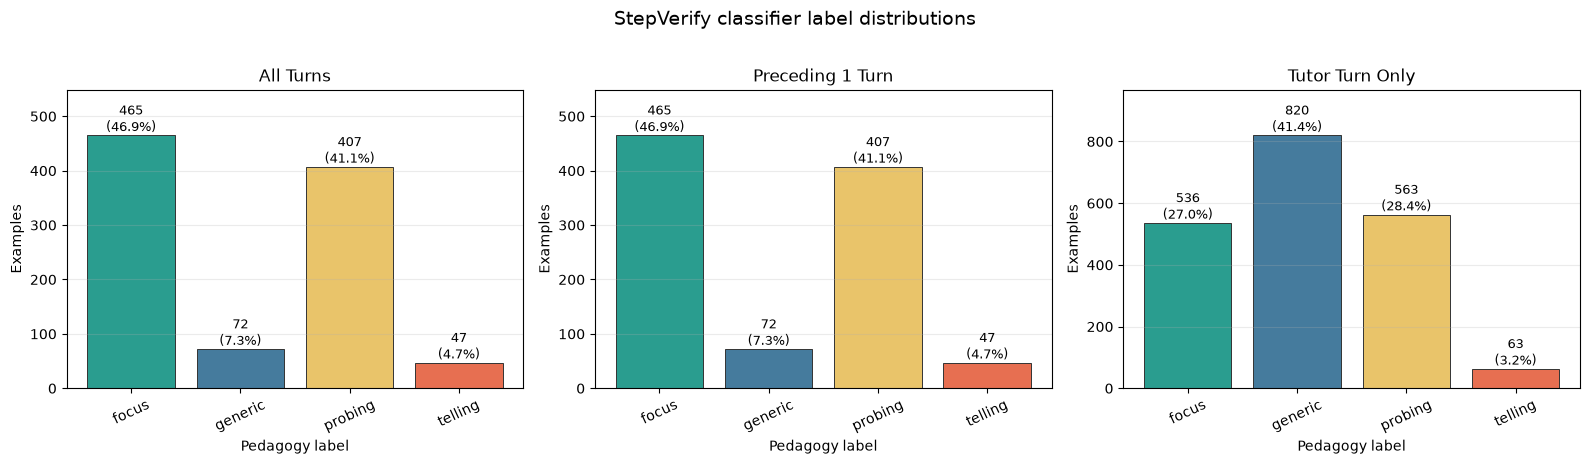

In [92]:
import matplotlib.pyplot as plt
import numpy as np

LABEL_ORDER = sorted(VALID_PEDAGOGY_LABELS)
LABEL_COLORS = {
    "focus": "#2A9D8F",
    "generic": "#457B9D",
    "probing": "#E9C46A",
    "telling": "#E76F51",
}

label_distribution_rows = []
class_imbalance_rows = []
for dataset_name, dataset_df in classification_datasets.items():
    label_counts = dataset_df["label"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    for label, count in label_counts.items():
        label_distribution_rows.append(
            {
                "dataset": dataset_name,
                "label": label,
                "count": int(count),
                "percentage": 100 * count / len(dataset_df),
            }
        )

    majority_label = label_counts.idxmax()
    minority_label = label_counts.idxmin()
    class_imbalance_rows.append(
        {
            "dataset": dataset_name,
            "majority_label": majority_label,
            "majority_count": int(label_counts.max()),
            "minority_label": minority_label,
            "minority_count": int(label_counts.min()),
            "majority_to_minority_ratio": label_counts.max() / label_counts.min(),
        }
    )

label_distribution_df = pd.DataFrame(label_distribution_rows)
class_imbalance_df = pd.DataFrame(class_imbalance_rows)

display(
    label_distribution_df.pivot(
        index="label", columns="dataset", values=["count", "percentage"]
    ).round(2)
)
display(class_imbalance_df.round({"majority_to_minority_ratio": 2}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
for axis, (dataset_name, dataset_df) in zip(axes, classification_datasets.items()):
    counts = dataset_df["label"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    bars = axis.bar(
        counts.index,
        counts.values,
        color=[LABEL_COLORS[label] for label in counts.index],
        edgecolor="#333333",
        linewidth=0.7,
    )
    axis.set_title(dataset_name.replace("_", " ").title())
    axis.set_xlabel("Pedagogy label")
    axis.set_ylabel("Examples")
    axis.set_ylim(0, counts.max() * 1.18)
    axis.grid(axis="y", alpha=0.25)
    axis.tick_params(axis="x", rotation=25)
    for bar, count in zip(bars, counts.values):
        axis.annotate(
            f"{count:,}\n({100 * count / len(dataset_df):.1f}%)",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.suptitle("StepVerify classifier label distributions", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

#### Tutor-turn position explains the distribution shift

The all-turns and one-preceding-turn views predict only the final (second) tutor turn. The tutor-only view contains both labeled tutor turns, so its label distribution is the sum of the two position-specific distributions below.

In [93]:
position_label_rows = []
for record in flow_final_stepverify:
    teacher_labels = [
        turn.get("pedagogy")
        for turn in record.get("dialog_history", [])
        if str(turn.get("user", "")).strip().lower() == "teacher"
        and turn.get("pedagogy") is not None
    ]
    assert len(teacher_labels) == 2
    for teacher_position, label in enumerate(teacher_labels, start=1):
        position_label_rows.append(
            {"teacher_position": teacher_position, "label": label}
        )

position_label_df = pd.DataFrame(position_label_rows)
position_label_counts_df = pd.crosstab(
    position_label_df["teacher_position"], position_label_df["label"]
).reindex(columns=LABEL_ORDER, fill_value=0)
position_label_percentages_df = (
    pd.crosstab(
        position_label_df["teacher_position"],
        position_label_df["label"],
        normalize="index",
    ).reindex(columns=LABEL_ORDER, fill_value=0)
    * 100
)

print("Tutor-turn position x pedagogy label (counts):")
display(position_label_counts_df)
print("Tutor-turn position x pedagogy label (row percentages):")
display(position_label_percentages_df.round(2))

Tutor-turn position x pedagogy label (counts):


label,focus,generic,probing,telling
teacher_position,,,,
1,71,748,156,16
2,465,72,407,47


Tutor-turn position x pedagogy label (row percentages):


label,focus,generic,probing,telling
teacher_position,,,,
1,7.16,75.48,15.74,1.61
2,46.92,7.27,41.07,4.74


### 7.2 RoBERTa token-length distributions

Token counts include RoBERTa special tokens and are measured **without truncation**. This makes the `> 512` columns a direct audit of examples that the downstream classifiers truncate from the left. The word-count analysis for tutor-only inputs corresponds to the original notebook's "sentence length" analysis; it is named word count here because it uses whitespace splitting.

,dataset,examples,mean,std,min,p25,median,p75,p95,p99,max,>512_count,>512_percentage
0,all_turns,991,128.16,43.10,24,101.5,131.0,156.0,194.5,233.10,298,0,0.0
1,preceding_1_turn,991,109.97,44.93,15,81.0,115.0,140.0,178.0,218.10,283,0,0.0
2,tutor_turn_only,1982,21.12,12.63,3,13.0,16.0,27.0,46.0,62.19,123,0,0.0


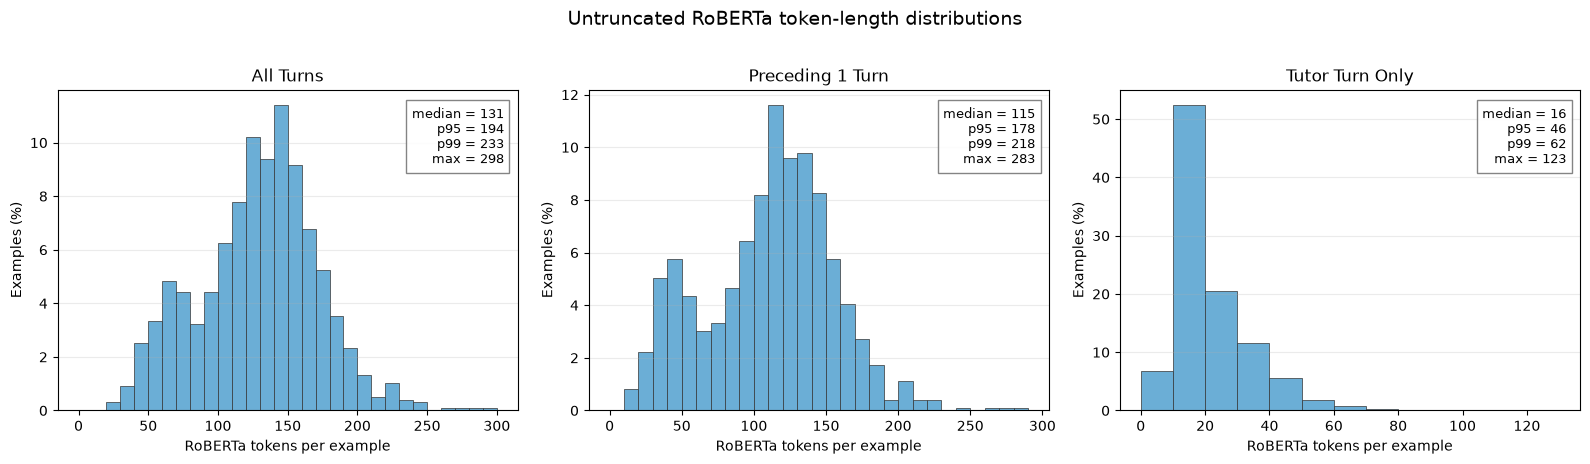

,dataset,examples,mean,std,min,p25,median,p75,p95,p99,max
0,tutor_turn_only,1982,16.03,10.9,1,9.0,12.0,21.0,37.0,52.0,110


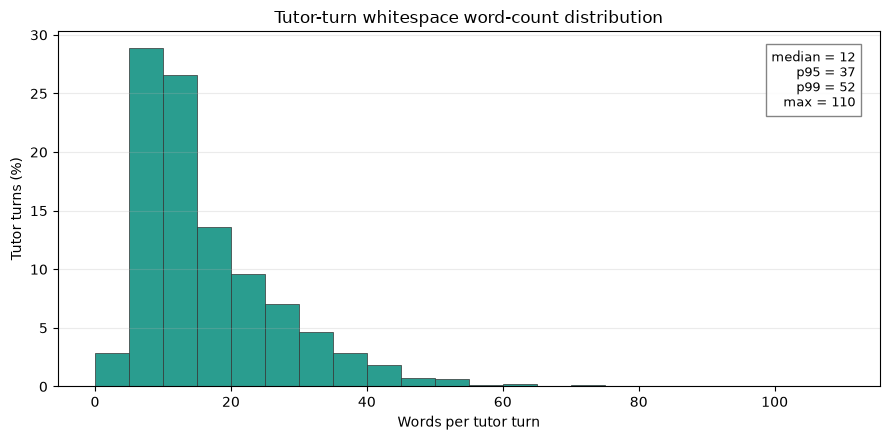

In [94]:
from transformers import AutoTokenizer

CLASSIFIER_MODEL_ID = "FacebookAI/roberta-base"
CLASSIFIER_MAX_TOKENS = 512
roberta_tokenizer = AutoTokenizer.from_pretrained(CLASSIFIER_MODEL_ID)
roberta_tokenizer.truncation_side = "left"


def distribution_summary(values: pd.Series, dataset_name: str) -> dict:
    return {
        "dataset": dataset_name,
        "examples": len(values),
        "mean": values.mean(),
        "std": values.std(),
        "min": values.min(),
        "p25": values.quantile(0.25),
        "median": values.median(),
        "p75": values.quantile(0.75),
        "p95": values.quantile(0.95),
        "p99": values.quantile(0.99),
        "max": values.max(),
        ">512_count": int(values.gt(CLASSIFIER_MAX_TOKENS).sum()),
        ">512_percentage": 100 * values.gt(CLASSIFIER_MAX_TOKENS).mean(),
    }


token_length_rows = []
for dataset_name, dataset_df in classification_datasets.items():
    encoded = roberta_tokenizer(
        dataset_df["text"].tolist(),
        add_special_tokens=True,
        truncation=False,
        padding=False,
        verbose=False,
    )["input_ids"]
    dataset_df["roberta_token_count"] = [len(input_ids) for input_ids in encoded]
    dataset_df["whitespace_word_count"] = dataset_df["text"].str.split().str.len()
    token_length_rows.append(
        distribution_summary(dataset_df["roberta_token_count"], dataset_name)
    )

token_length_summary_df = pd.DataFrame(token_length_rows)
display(token_length_summary_df.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for axis, (dataset_name, dataset_df) in zip(axes, classification_datasets.items()):
    token_counts = dataset_df["roberta_token_count"]
    bin_width = 10
    bins = np.arange(0, token_counts.max() + bin_width, bin_width)
    axis.hist(
        token_counts,
        bins=bins,
        weights=np.full(len(token_counts), 100 / len(token_counts)),
        color="#6BAED6",
        edgecolor="#333333",
        linewidth=0.5,
    )
    if token_counts.max() > CLASSIFIER_MAX_TOKENS:
        axis.axvline(
            CLASSIFIER_MAX_TOKENS,
            color="#C0392B",
            linestyle="--",
            linewidth=1.5,
            label="512-token limit",
        )
        axis.legend(frameon=False)
    axis.set_title(dataset_name.replace("_", " ").title())
    axis.set_xlabel("RoBERTa tokens per example")
    axis.set_ylabel("Examples (%)")
    axis.grid(axis="y", alpha=0.25)
    axis.text(
        0.97,
        0.95,
        f"median = {token_counts.median():.0f}\n"
        f"p95 = {token_counts.quantile(0.95):.0f}\n"
        f"p99 = {token_counts.quantile(0.99):.0f}\n"
        f"max = {token_counts.max():.0f}",
        transform=axis.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "#777777", "alpha": 0.9},
    )

fig.suptitle("Untruncated RoBERTa token-length distributions", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

tutor_word_counts = classification_datasets["tutor_turn_only"]["whitespace_word_count"]
tutor_word_summary_df = pd.DataFrame(
    [distribution_summary(tutor_word_counts, "tutor_turn_only")]
).drop(columns=[">512_count", ">512_percentage"])
display(tutor_word_summary_df.round(2))

fig, axis = plt.subplots(figsize=(9, 4.5))
word_bin_width = 5
word_bins = np.arange(0, tutor_word_counts.max() + word_bin_width, word_bin_width)
axis.hist(
    tutor_word_counts,
    bins=word_bins,
    weights=np.full(len(tutor_word_counts), 100 / len(tutor_word_counts)),
    color="#2A9D8F",
    edgecolor="#333333",
    linewidth=0.5,
)
axis.set_title("Tutor-turn whitespace word-count distribution")
axis.set_xlabel("Words per tutor turn")
axis.set_ylabel("Tutor turns (%)")
axis.grid(axis="y", alpha=0.25)
axis.text(
    0.97,
    0.95,
    f"median = {tutor_word_counts.median():.0f}\n"
    f"p95 = {tutor_word_counts.quantile(0.95):.0f}\n"
    f"p99 = {tutor_word_counts.quantile(0.99):.0f}\n"
    f"max = {tutor_word_counts.max():.0f}",
    transform=axis.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox={"facecolor": "white", "edgecolor": "#777777", "alpha": 0.9},
)
fig.tight_layout()
plt.show()

### 7.3 Downstream split, class-weight, and leakage diagnostics

The classifier notebooks perform a row-level, label-stratified split with `SEED = 42`: 20% test data is separated first, then 25% of the remaining 80% is used for validation. This produces an approximately **60% / 20% / 20%** train/validation/test split.

For the tutor-only view, the audit below reconstructs each row's source-conversation ID from the final labeled JSON and verifies that the reconstructed text-label sequence exactly matches the saved CSV before measuring cross-split overlap.

In [95]:
from itertools import combinations

from sklearn.model_selection import train_test_split

from final__clean_transform_datasets import normalize_text

CLASSIFIER_SPLIT_SEED = 42

# Reconstruct tutor-only row lineage and verify it against the saved classifier CSV.
tutor_turn_lineage_rows = []
for source_conversation_id, record in enumerate(flow_final_stepverify):
    teacher_position = 0
    for turn in record.get("dialog_history", []):
        if str(turn.get("user", "")).strip().lower() != "teacher":
            continue
        if turn.get("pedagogy") is None:
            continue
        normalized_text = normalize_text(turn.get("text", ""))
        if not normalized_text:
            continue
        teacher_position += 1
        tutor_turn_lineage_rows.append(
            {
                "text": normalized_text,
                "label": turn["pedagogy"],
                "source_conversation_id": source_conversation_id,
                "teacher_position": teacher_position,
            }
        )

tutor_turn_lineage_df = pd.DataFrame(tutor_turn_lineage_rows)
tutor_only_csv_df = classification_datasets["tutor_turn_only"]
assert len(tutor_turn_lineage_df) == 2 * len(flow_final_stepverify)
assert tutor_turn_lineage_df[["text", "label"]].reset_index(drop=True).equals(
    tutor_only_csv_df[["text", "label"]].reset_index(drop=True)
)
assert tutor_turn_lineage_df.groupby("source_conversation_id").size().eq(2).all()

split_input_datasets = {}
for dataset_name, dataset_df in classification_datasets.items():
    split_input_df = dataset_df[["text", "label"]].copy()
    if dataset_name == "tutor_turn_only":
        split_input_df["source_conversation_id"] = tutor_turn_lineage_df[
            "source_conversation_id"
        ].to_numpy()
    else:
        split_input_df["source_conversation_id"] = np.arange(len(split_input_df))
    split_input_datasets[dataset_name] = split_input_df


def split_like_downstream_classifier(dataset_df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    work_df = dataset_df.copy()
    label_to_id = {label: label_id for label_id, label in enumerate(LABEL_ORDER)}
    work_df["labels"] = work_df["label"].map(label_to_id).astype(int)

    train_validation_df, test_df = train_test_split(
        work_df,
        test_size=0.2,
        random_state=CLASSIFIER_SPLIT_SEED,
        stratify=work_df["labels"],
    )
    train_df, validation_df = train_test_split(
        train_validation_df,
        test_size=0.25,
        random_state=CLASSIFIER_SPLIT_SEED,
        stratify=train_validation_df["labels"],
    )
    return {"train": train_df, "validation": validation_df, "test": test_df}


classifier_splits = {
    dataset_name: split_like_downstream_classifier(dataset_df)
    for dataset_name, dataset_df in split_input_datasets.items()
}

split_distribution_rows = []
class_weight_rows = []
split_overlap_rows = []
for dataset_name, split_dfs in classifier_splits.items():
    for split_name, split_df in split_dfs.items():
        label_counts = split_df["label"].value_counts().reindex(LABEL_ORDER, fill_value=0)
        split_distribution_rows.append(
            {
                "dataset": dataset_name,
                "split": split_name,
                "examples": len(split_df),
                "source_conversations": split_df["source_conversation_id"].nunique(),
                **{label: int(label_counts[label]) for label in LABEL_ORDER},
            }
        )

    train_counts = (
        split_dfs["train"]["label"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    )
    assert train_counts.gt(0).all()
    for label, count in train_counts.items():
        class_weight_rows.append(
            {
                "dataset": dataset_name,
                "label": label,
                "train_count": int(count),
                "balanced_CE_weight": len(split_dfs["train"]) / (len(LABEL_ORDER) * count),
            }
        )

    text_sets = {
        split_name: set(split_df["text"])
        for split_name, split_df in split_dfs.items()
    }
    pair_sets = {
        split_name: set(zip(split_df["text"], split_df["label"]))
        for split_name, split_df in split_dfs.items()
    }
    conversation_sets = {
        split_name: set(split_df["source_conversation_id"])
        for split_name, split_df in split_dfs.items()
    }

    shared_texts = set().union(
        *(text_sets[left] & text_sets[right] for left, right in combinations(text_sets, 2))
    )
    shared_pairs = set().union(
        *(pair_sets[left] & pair_sets[right] for left, right in combinations(pair_sets, 2))
    )
    shared_conversations = set().union(
        *(
            conversation_sets[left] & conversation_sets[right]
            for left, right in combinations(conversation_sets, 2)
        )
    )
    rows_with_shared_text = sum(
        split_df["text"].isin(shared_texts).sum() for split_df in split_dfs.values()
    )

    split_overlap_rows.append(
        {
            "dataset": dataset_name,
            "unique_texts_shared_across_splits": len(shared_texts),
            "rows_with_text_seen_in_another_split": int(rows_with_shared_text),
            "exact_text_label_pairs_shared_across_splits": len(shared_pairs),
            "source_conversations_shared_across_splits": len(shared_conversations),
        }
    )

split_distribution_df = pd.DataFrame(split_distribution_rows)
classifier_class_weights_df = pd.DataFrame(class_weight_rows)
classifier_split_overlap_df = pd.DataFrame(split_overlap_rows)

print("Exact split sizes and label supports used by downstream experiments:")
display(split_distribution_df)
print("Balanced cross-entropy weights computed from each training split:")
display(classifier_class_weights_df.round({"balanced_CE_weight": 3}))
print("Cross-split overlap diagnostics:")
display(classifier_split_overlap_df)

Exact split sizes and label supports used by downstream experiments:


,dataset,split,examples,source_conversations,focus,generic,probing,telling
0,all_turns,train,594,594,279,43,244,28
1,all_turns,validation,198,198,93,14,81,10
2,all_turns,test,199,199,93,15,82,9
3,preceding_1_turn,train,594,594,279,43,244,28
4,preceding_1_turn,validation,198,198,93,14,81,10
5,preceding_1_turn,test,199,199,93,15,82,9
6,tutor_turn_only,train,1188,832,322,492,337,37
7,tutor_turn_only,validation,397,362,107,164,113,13
8,tutor_turn_only,test,397,352,107,164,113,13


Balanced cross-entropy weights computed from each training split:


,dataset,label,train_count,balanced_CE_weight
0,all_turns,focus,279,0.532
1,all_turns,generic,43,3.453
2,all_turns,probing,244,0.609
3,all_turns,telling,28,5.304
4,preceding_1_turn,focus,279,0.532
5,preceding_1_turn,generic,43,3.453
6,preceding_1_turn,probing,244,0.609
7,preceding_1_turn,telling,28,5.304
8,tutor_turn_only,focus,322,0.922
9,tutor_turn_only,generic,492,0.604


Cross-split overlap diagnostics:


,dataset,unique_texts_shared_across_splits,rows_with_text_seen_in_another_split,exact_text_label_pairs_shared_across_splits,source_conversations_shared_across_splits
0,all_turns,0,0,0,0
1,preceding_1_turn,0,0,0,0
2,tutor_turn_only,40,288,40,555


In [96]:
pairwise_overlap_rows = []
for dataset_name, split_dfs in classifier_splits.items():
    for left_split, right_split in combinations(["train", "validation", "test"], 2):
        left_df = split_dfs[left_split]
        right_df = split_dfs[right_split]
        shared_texts = set(left_df["text"]) & set(right_df["text"])
        shared_pairs = set(zip(left_df["text"], left_df["label"])) & set(
            zip(right_df["text"], right_df["label"])
        )
        shared_conversations = set(left_df["source_conversation_id"]) & set(
            right_df["source_conversation_id"]
        )
        pairwise_overlap_rows.append(
            {
                "dataset": dataset_name,
                "split_pair": f"{left_split} - {right_split}",
                "shared_unique_texts": len(shared_texts),
                "shared_exact_text_label_pairs": len(shared_pairs),
                "shared_source_conversations": len(shared_conversations),
            }
        )

pairwise_split_overlap_df = pd.DataFrame(pairwise_overlap_rows)
display(pairwise_split_overlap_df)

,dataset,split_pair,shared_unique_texts,shared_exact_text_label_pairs,shared_source_conversations
0,all_turns,train - validation,0,0,0
1,all_turns,train - test,0,0,0
2,all_turns,validation - test,0,0,0
3,preceding_1_turn,train - validation,0,0,0
4,preceding_1_turn,train - test,0,0,0
5,preceding_1_turn,validation - test,0,0,0
6,tutor_turn_only,train - validation,21,21,248
7,tutor_turn_only,train - test,28,28,228
8,tutor_turn_only,validation - test,17,17,79


In [97]:
heldout_overlap_rows = []
comparison_specs = [
    ("validation", ["train"]),
    ("test", ["train"]),
    ("test", ["train", "validation"]),
]
for dataset_name, split_dfs in classifier_splits.items():
    for heldout_name, reference_names in comparison_specs:
        heldout_df = split_dfs[heldout_name]
        reference_texts = set().union(
            *(set(split_dfs[name]["text"]) for name in reference_names)
        )
        reference_conversations = set().union(
            *(set(split_dfs[name]["source_conversation_id"]) for name in reference_names)
        )
        overlapping_texts = set(heldout_df["text"]) & reference_texts
        overlapping_conversations = (
            set(heldout_df["source_conversation_id"]) & reference_conversations
        )
        heldout_overlap_rows.append(
            {
                "dataset": dataset_name,
                "heldout_split": heldout_name,
                "reference_split": "+".join(reference_names),
                "heldout_unique_texts": heldout_df["text"].nunique(),
                "overlapping_unique_texts": len(overlapping_texts),
                "heldout_rows_with_overlapping_text": int(
                    heldout_df["text"].isin(overlapping_texts).sum()
                ),
                "heldout_source_conversations": heldout_df[
                    "source_conversation_id"
                ].nunique(),
                "overlapping_source_conversations": len(overlapping_conversations),
                "source_conversation_overlap_percentage": (
                    100
                    * len(overlapping_conversations)
                    / heldout_df["source_conversation_id"].nunique()
                ),
            }
        )

heldout_split_overlap_df = pd.DataFrame(heldout_overlap_rows)
display(heldout_split_overlap_df.round({"source_conversation_overlap_percentage": 2}))

,dataset,heldout_split,reference_split,heldout_unique_texts,overlapping_unique_texts,heldout_rows_with_overlapping_text,heldout_source_conversations,overlapping_source_conversations,source_conversation_overlap_percentage
0,all_turns,validation,train,198,0,0,198,0,0.00
1,all_turns,test,train,199,0,0,199,0,0.00
2,all_turns,test,train+validation,199,0,0,199,0,0.00
3,preceding_1_turn,validation,train,198,0,0,198,0,0.00
4,preceding_1_turn,test,train,199,0,0,199,0,0.00
5,preceding_1_turn,test,train+validation,199,0,0,199,0,0.00
6,tutor_turn_only,validation,train,362,21,56,362,248,68.51
7,tutor_turn_only,test,train,354,28,68,352,228,64.77
8,tutor_turn_only,test,train+validation,354,32,74,352,307,87.22


### 7.4 Verified classifier-data findings

- The **all-turns** and **one-preceding-turn** views each contain **991 conversation-level examples**. Their target-label distributions are identical because both predict the second (final) tutor turn: `focus` 465 (46.92%), `generic` 72 (7.27%), `probing` 407 (41.07%), and `telling` 47 (4.74%). The majority-to-minority ratio is **9.89:1**.
- The **tutor-only** view contains **1,982 tutor-turn examples**, exactly two for each of the 991 retained conversations: `focus` 536 (27.04%), `generic` 820 (41.37%), `probing` 563 (28.41%), and `telling` 63 (3.18%). Its majority-to-minority ratio is **13.02:1**.
- The distribution shift is positional. Among first tutor turns, `generic` accounts for **748/991 (75.48%)**; among second tutor turns, `focus` and `probing` account for **465/991 (46.92%)** and **407/991 (41.07%)**, respectively.
- None of the three views exceeds RoBERTa's 512-token limit. The maximum untruncated lengths are **298**, **283**, and **123** tokens for all-turns, one-preceding-turn, and tutor-only inputs, respectively. Thus left truncation does not remove content in these datasets.
- With the exact downstream `SEED = 42` stratified split, the two conversation-level datasets contain **594/198/199** train/validation/test examples. The tutor-only dataset contains **1,188/397/397** examples.
- The minority `telling` class has only **28** training examples in each conversation-level view and **37** in the tutor-only view. The corresponding balanced cross-entropy weights are **5.304** and **8.027**, which documents why imbalance-aware losses and macro/per-class metrics are needed.
- The conversation-level views have no repeated texts, conflicting labels, or cross-split source-conversation overlap.
- The tutor-only view has **1,719 unique texts among 1,982 rows**. There are 51 repeated unique texts, 263 repeated-text rows beyond the first occurrence, 258 exact `(text, label)` duplicate rows beyond the first occurrence, and 5 texts associated with conflicting labels.
- Under the current row-level tutor-only split, **40 unique texts** and **555 source conversations** occur in more than one split. In particular, 28 exact texts and 228 source conversations are shared between train and test. Of the 352 source conversations represented in test, **228 (64.77%)** also occur in train and **307 (87.22%)** occur in train or validation.

**Interpretation.** The existing all-turns and one-preceding-turn splits are independent at the retained-conversation level. The tutor-only split is not: its two turns from one source conversation can be assigned to different splits, and repeated normalized utterances can also cross split boundaries. Therefore, tutor-only scores from the current row-level split should be described as **turn-level random-split performance**, not as performance on wholly unseen conversations. For a conversation-independent evaluation, preserve `source_conversation_id` during CSV construction and use a group-aware split before training.